In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window_same_input_output
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [3]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 4  # one qubit per feature (tide_deriv, form_fac, high_t_evt, tide_height)

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window_same_input_output(
    filtered_time, data_orig, n_previous_events
)

print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())
display(y_train.iloc[0])

X shape:  (2822, 84)
y shape:  (2822, 4)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
high_t_evt-0      0
tide_height-0     0
tide_deriv-1      0
                 ..
tide_height-19    0
tide_deriv-20     0
form_fac-20       0
high_t_evt-20     0
tide_height-20    0
Length: 84, dtype: int64
Total NaN: 0


tide_deriv    -0.008337
form_fac       0.995725
high_t_evt     1.000000
tide_height    7.292050
Name: 339, dtype: float64

In [4]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "topology": "nn",           # Opt-NN-TFI (nearest-neighbour open chain)
    "num_layers_per_event": 1,  # 1 layer for NN (2 for FC-TFI)
    "shots": 1024,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "XGBoost"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'topology': 'nn', 'num_layers_per_event': 1, 'shots': 1024, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: XGBoost


In [5]:
# ── Cell 5: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits
n_total_events = n_previous_events + 1

expected_cols = n_total_events * n_qubits
if X_train_q.shape[1] != expected_cols:
    raise ValueError(
        f"Feature width mismatch: got {X_train_q.shape[1]} columns but the "
        f"reservoir expects {expected_cols} ({n_total_events} events × "
        f"{n_qubits} qubits / features)."
    )

print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")
print(f"Total events per sample: {n_total_events}")


Input to quantum circuit: (1692, 84)
n_qubits: 4, n_states: 16
Total events per sample: 21


In [6]:
# ── Cell 6: Raw features for classical XGBoost path ───
X_train_raw = X_train.to_numpy()
X_val_raw   = X_val.to_numpy()
X_test_raw  = X_test.to_numpy()


In [7]:
# ── Cell 7: Opt-NN-TFI Hamiltonian ──────────────────────────────────────────
# Nearest-neighbour open chain (Shallow-Arch.ipynb / noisy_qrc_slurm topology="nn")

def generate_ising_params(n_qubits, rng, J_std=0.5, h=0.5, t=0.1):
    """Sample random NN coupling constants J_{i,i+1} ~ U(-J_std, J_std)."""
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits - 1):
        J[i, i + 1] = rng.uniform(-J_std, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=1):
    """First-order Trotterization of NN-TFI Hamiltonian."""
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits - 1):
            if abs(J[i, i + 1]) > 1e-10:
                qc.cx(i, i + 1)
                qc.rz(2 * J[i, i + 1] * dt, i + 1)
                qc.cx(i, i + 1)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


def build_reservoir_circuit_rotations(data_sample, ising_params, num_layers, n_qubits):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)

    for i in range(n_qubits):
        qc.h(i)

    encode_rotations(qc, data_sample, n_qubits)
    qc.barrier()

    for _layer in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()
        encode_rotations(qc, data_sample, n_qubits)
        qc.barrier()
        trotter_ising_layer(qc, n_qubits, J, h, t)
        qc.barrier()

    return qc


def generate_random_angles(num_layers, n_qubits, rng):
    return generate_ising_params(n_qubits, rng)


In [8]:
# ── Cell 8: Pauli runner — quantum features only, no classical concatenation ───
def get_pauli_expectations(circuit_base, n_qubits, shots, simulator):
    expectations = np.zeros(3 * n_qubits)

    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        qc_meas = circuit_base.copy()

        if basis == 'X':
            for i in range(n_qubits):
                qc_meas.h(i)
        elif basis == 'Y':
            for i in range(n_qubits):
                qc_meas.sdg(i)
                qc_meas.h(i)

        qc_meas.measure_all()
        result = simulator.run(qc_meas, shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            bits = bitstring.replace(" ", "")
            for qubit_idx in range(n_qubits):
                bit = int(bits[n_qubits - 1 - qubit_idx])
                expectations[basis_idx * n_qubits + qubit_idx] += (
                    (1 - 2 * bit) * count / shots
                )

    # NN ZZ correlators only (i, i+1) — open-chain topology
    zz_correlators = np.zeros(n_qubits)
    qc_zz = circuit_base.copy()
    qc_zz.measure_all()
    result_zz = simulator.run(qc_zz, shots=shots).result()
    counts_zz = result_zz.get_counts()

    for bitstring, count in counts_zz.items():
        bits = bitstring.replace(" ", "")
        for i in range(n_qubits - 1):
            j = i + 1
            bit_i = int(bits[n_qubits - 1 - i])
            bit_j = int(bits[n_qubits - 1 - j])
            zz_correlators[i] += (
                (1 - 2 * bit_i) * (1 - 2 * bit_j) * count / shots
            )

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli(
    X_data, angle_bank, num_layers, n_qubits, n_total_events, shots
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m         = X_data.shape[0]
    n_obs     = 3 * n_qubits + n_qubits  
    simulator = AerSimulator()
    pauli_matrix = np.zeros((m, n_total_events * n_obs))

    for event_idx in range(n_total_events):
        start_col    = event_idx * n_qubits
        end_col      = start_col + n_qubits
        X_event      = X_data[:, start_col:end_col]
        ising_params = angle_bank[event_idx]

        for sample_idx in range(m):
            qc = build_reservoir_circuit_rotations(
                X_event[sample_idx], ising_params, num_layers, n_qubits
            )
            obs_vals = get_pauli_expectations(qc, n_qubits, shots, simulator)
            pauli_matrix[
                sample_idx,
                event_idx * n_obs:(event_idx + 1) * n_obs
            ] = obs_vals

        print(f"  Event {event_idx + 1}/{n_total_events} done", end="\r")

    print()
    return pauli_matrix


def make_hybrid_features_decay(P_matrix, X_classical, n_total_events, n_obs, decay=0.3):
    weights = np.array([
        np.exp(-decay * (n_total_events - 1 - i))
        for i in range(n_total_events)
    ])
    weights /= weights.sum()

    weighted_P = P_matrix.copy()
    for event_idx in range(n_total_events):
        start = event_idx * n_obs
        end   = start + n_obs
        weighted_P[:, start:end] *= weights[event_idx]
    return weighted_P


In [9]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # plain fit, no eval_set 
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: XGBoost


In [10]:
# ── Cell 10: Single iteration — unified reservoir ──────
def run_single_qrc_iteration(
    iteration_idx,
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    num_layers     = config["num_layers_per_event"]
    shots          = config["shots"]
    seed           = config["random_seed"] + iteration_idx
    n_total_events = n_previous_events + 1
    n_obs          = 3 * n_qubits + n_qubits  # 16 for 4 qubits

    rng = np.random.default_rng(seed)
    angle_bank = [
        generate_random_angles(num_layers, n_qubits, rng)
        for _ in range(n_total_events)
    ]

    print(f"  Train: {len(y_train_np)}, val: {len(y_val_np)}, test: {len(y_test_np)}")

    print(f"  Running Opt-NN-TFI reservoir on train ({len(X_train_q)} samples)...")
    P_tr = run_quantum_reservoir_pauli(
        X_train_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running Opt-NN-TFI reservoir on val ({len(X_val_q)} samples)...")
    P_vl = run_quantum_reservoir_pauli(
        X_val_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )
    print(f"  Running Opt-NN-TFI reservoir on test ({len(X_test_q)} samples)...")
    P_te = run_quantum_reservoir_pauli(
        X_test_q, angle_bank, num_layers, n_qubits, n_total_events, shots
    )

    H_tr = make_hybrid_features_decay(P_tr, X_train_q, n_total_events, n_obs)
    H_vl = make_hybrid_features_decay(P_vl, X_val_q, n_total_events, n_obs)
    H_te = make_hybrid_features_decay(P_te, X_test_q, n_total_events, n_obs)

    entry = registry[model_name]

    from sklearn.model_selection import KFold

    _n_cv_folds = 3

    def _cv_mae(entry, params, H_tr, y_tr, rng_seed):
        kf = KFold(n_splits=_n_cv_folds, shuffle=True, random_state=rng_seed)
        maes = []
        optuna_fit = entry.get("optuna_fit_fn", lambda m, Xt, yt: m.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_tr):
            m = entry["build_fn"](params)
            optuna_fit(m, H_tr[fold_tr], y_tr[fold_tr])
            maes.append(mean_absolute_error(y_tr[fold_vl], m.predict(H_tr[fold_vl])))
        return float(np.mean(maes))

    def objective(trial):
        tuned  = entry["optuna_fn"](trial)
        params = {**entry["fixed_params"], **tuned}
        return _cv_mae(entry, params, H_tr, y_train_np, seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=30)

    tuned  = entry["optuna_fn"](study.best_trial)
    params = {**entry["fixed_params"], **tuned}
    model  = entry["build_fn"](params)
    entry["fit_fn"](model, H_tr, y_train_np, H_vl, y_val_np)

    val_mae = mean_absolute_error(y_val_np, model.predict(H_vl))
    print(f"  Val MAE: {val_mae:.2f}s")

    test_pred = model.predict(H_te)
    val_pred  = model.predict(H_vl)

    return {
        "iteration":   iteration_idx,
        "val_r2":      r2_score(y_val_np, val_pred),
        "val_rmse":    root_mean_squared_error(y_val_np, val_pred),
        "val_mae":     mean_absolute_error(y_val_np, val_pred),
        "test_rmse":   root_mean_squared_error(y_test_np, test_pred),
        "test_mae":    mean_absolute_error(y_test_np, test_pred),
        "test_pred":   test_pred,
        "best_params": params,
        "model":       model,
        "P_train":     P_tr,
        "P_val":       P_vl,
        "P_test":      P_te,
    }


In [11]:
# ── Cell 11: Pipeline + run ───────────────────────────────────────────────────
def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, config, model_name, registry,
):
    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            X_train_q, X_val_q, X_test_q,
            y_train, y_val, y_test,
            n_qubits, config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred  = all_test_preds.mean(axis=0)
    ensemble_rmse  = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae   = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2    = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble (all {len(results)} iterations — primary headline):")
    print(f"  Test RMSE: {ensemble_rmse:.2f}")
    print(f"  Test MAE:  {ensemble_mae:.2f}")
    print(f"  Test R2:   {ensemble_r2:.4f}")

    top_k          = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results    = sorted_results[:top_k]
    top_indices    = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae  = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2   = r2_score(y_test_np, top_k_pred)

    print(f"\nTop-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"  Iterations: {[i + 1 for i in top_indices]}")
    print(f"  Test RMSE: {top_k_rmse:.2f}")
    print(f"  Test MAE:  {top_k_mae:.2f}")
    print(f"  Test R2:   {top_k_r2:.4f}")

    return results, ensemble_pred, top_indices


all_results, ensemble_pred, top_indices = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train, y_val, y_test,
    n_qubits, QRC_CONFIG,
    "XGBoost",
    registry,
)



Iteration 1/5:
  Train: 1692, val: 565, test: 565
  Running Opt-NN-TFI reservoir on train (1692 samples)...


  Event 21/21 done
  Running Opt-NN-TFI reservoir on val (565 samples)...
  Event 21/21 done
  Running Opt-NN-TFI reservoir on test (565 samples)...
  Event 21/21 done
  Val MAE: 7.64s
	Val R2: 0.2660 | Val RMSE: 10.20 | Val MAE: 7.64 | Test RMSE: 11.18 | Test MAE: 8.69

Iteration 2/5:
  Train: 1692, val: 565, test: 565
  Running Opt-NN-TFI reservoir on train (1692 samples)...
  Event 21/21 done
  Running Opt-NN-TFI reservoir on val (565 samples)...
  Event 21/21 done
  Running Opt-NN-TFI reservoir on test (565 samples)...
  Event 21/21 done
  Val MAE: 7.67s
	Val R2: 0.2900 | Val RMSE: 10.35 | Val MAE: 7.67 | Test RMSE: 11.02 | Test MAE: 8.68

Iteration 3/5:
  Train: 1692, val: 565, test: 565
  Running Opt-NN-TFI reservoir on train (1692 samples)...
  Event 21/21 done
  Running Opt-NN-TFI reservoir on val (565 samples)...
  Event 21/21 done
  Running Opt-NN-TFI reservoir on test (565 samples)...
  Event 21/21 done
  Val MAE: 7.61s
	Val R2: 0.2711 | Val RMSE: 10.29 | Val MAE: 7.61 | Tes

In [12]:
# ── Cell 12: Classical XGBoost + multi-output evaluation helpers ───────────
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

TARGET_NAMES = list(feature_cols)

X_train_np = X_train_raw
X_val_np   = X_val_raw
X_test_np  = X_test_raw

print(f"Training samples: {len(y_train_np)}")

_N_CV = 3

def _xgb_cv_rmse(X_tr, y_tr, params, n_folds=_N_CV, seed=42):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, vl_idx in kf.split(X_tr):
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=False)
        rmses.append(root_mean_squared_error(y_tr[vl_idx], m.predict(X_tr[vl_idx])))
    return float(np.mean(rmses))

_search_params = dict(
    objective="reg:squarederror",
    n_estimators=2000,
)

def objective_xgb(trial):
    params = {
        **_search_params,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 5),
        "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
    }
    return _xgb_cv_rmse(X_train_np, y_train_np, params, seed=42)

opt_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
opt_study.optimize(objective_xgb, n_trials=30)
print("Optimal params:", opt_study.best_params)

XGBoost_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    **opt_study.best_params,
    random_state=42,
)
XGBoost_model.fit(X_train_np, y_train_np, verbose=False)

final_predictions = XGBoost_model.predict(X_test_np)

# ── Shared helpers for 4-feature targets (n_samples × 4) ─────────────────────
def as_target_matrix(y):
    arr = np.asarray(y, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != len(TARGET_NAMES):
        raise ValueError(f"Expected shape (n, {len(TARGET_NAMES)}), got {arr.shape}")
    return arr

def per_feature_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=0)

def per_sample_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=1)

def multioutput_r2(y_true, y_pred):
    return r2_score(y_true, y_pred, multioutput="variance_weighted")

def feature_limits(y_true, y_pred, pad_frac=0.05):
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    pad = (hi - lo) * pad_frac if hi > lo else 1.0
    return lo - pad, hi + pad

def plot_feature_parity(ax, y_true, y_pred, feat_idx, title="", limits=None):
    yt = y_true[:, feat_idx]
    yp = y_pred[:, feat_idx]
    if limits is None:
        lo, hi = feature_limits(yt, yp)
    else:
        lo, hi = limits
    ax.scatter(yt, yp, s=14, alpha=0.55, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    mae = np.mean(np.abs(yt - yp))
    r2 = r2_score(yt, yp)
    ax.set_title(f"{title}\nMAE={mae:.3f}, R²={r2:.3f}", fontsize=9)
    ax.set_xlabel(f"True {TARGET_NAMES[feat_idx]}")
    ax.set_ylabel(f"Pred {TARGET_NAMES[feat_idx]}")

y_test_true = as_target_matrix(y_test_np)
classical_pred = as_target_matrix(final_predictions)

overall_RMSE = root_mean_squared_error(y_test_true, classical_pred)
overall_MAE  = mean_absolute_error(y_test_true, classical_pred)

print("\n=== Classical XGBoost — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.4f}")
print(f"MAE:  {overall_MAE:.4f}")
print(f"R²:   {multioutput_r2(y_test_true, classical_pred):.4f}")
print("Per-feature MAE:")
for name, mae in zip(TARGET_NAMES, per_feature_mae(y_test_true, classical_pred)):
    print(f"  {name}: {mae:.4f}")


Training samples: 1692
Optimal params: {'learning_rate': 0.010605948032460264, 'max_depth': 5, 'subsample': 0.6389395024625302, 'colsample_bytree': 0.6991352933396707}

=== Classical XGBoost — Overall Test Performance ===
RMSE: 11.1739
MAE:  8.4199
R²:   0.0408
Per-feature MAE:
  tide_deriv: 0.0921
  form_fac: 1.2384
  high_t_evt: 0.4217
  tide_height: 31.9274


In [13]:
# ── Cell 13: Per-feature metrics table (Classical + QRC) ───────────────────
import pandas as pd

try:
    qrc_pred = as_target_matrix(ensemble_pred)
    _qrc_available = True
except NameError:
    qrc_pred = None
    _qrc_available = False

rows = []
for label, preds in [("Classical XGBoost", classical_pred)] + (
    [("Noiseless QRC", qrc_pred)] if _qrc_available else []
):
    pf_mae = per_feature_mae(y_test_true, preds)
    row = {
        "Model": label,
        "MAE (avg)": mean_absolute_error(y_test_true, preds),
        "RMSE": root_mean_squared_error(y_test_true, preds),
        "R²": multioutput_r2(y_test_true, preds),
    }
    for name, m in zip(TARGET_NAMES, pf_mae):
        row[f"MAE ({name})"] = m
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index("Model")
print("Per-feature test metrics")
print("=" * 80)
display(metrics_df.round(4))


Per-feature test metrics


,MAE (avg),RMSE,R²,MAE (tide_deriv),MAE (form_fac),MAE (high_t_evt),MAE (tide_height)
Model,,,,,,,
Classical XGBoost,8.4199,11.1739,0.0408,0.0921,1.2384,0.4217,31.9274
Noiseless QRC,8.6737,11.0746,0.0481,0.0958,1.1281,0.4221,33.0489


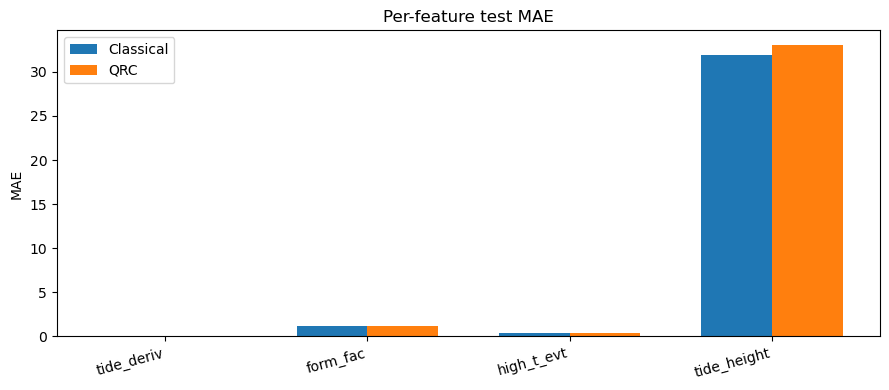

In [14]:
# ── Cell 14: Per-feature MAE bar chart ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

models = [("Classical", classical_pred)]
if _qrc_available:
    models.append(("QRC", qrc_pred))

x = np.arange(len(TARGET_NAMES))
width = 0.35 if len(models) == 2 else 0.5

fig, ax = plt.subplots(figsize=(9, 4))
for i, (label, preds) in enumerate(models):
    offset = (i - (len(models) - 1) / 2) * width
    ax.bar(x + offset, per_feature_mae(y_test_true, preds), width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(TARGET_NAMES, rotation=15, ha="right")
ax.set_ylabel("MAE")
ax.set_title("Per-feature test MAE")
ax.legend()
plt.tight_layout()
plt.show()


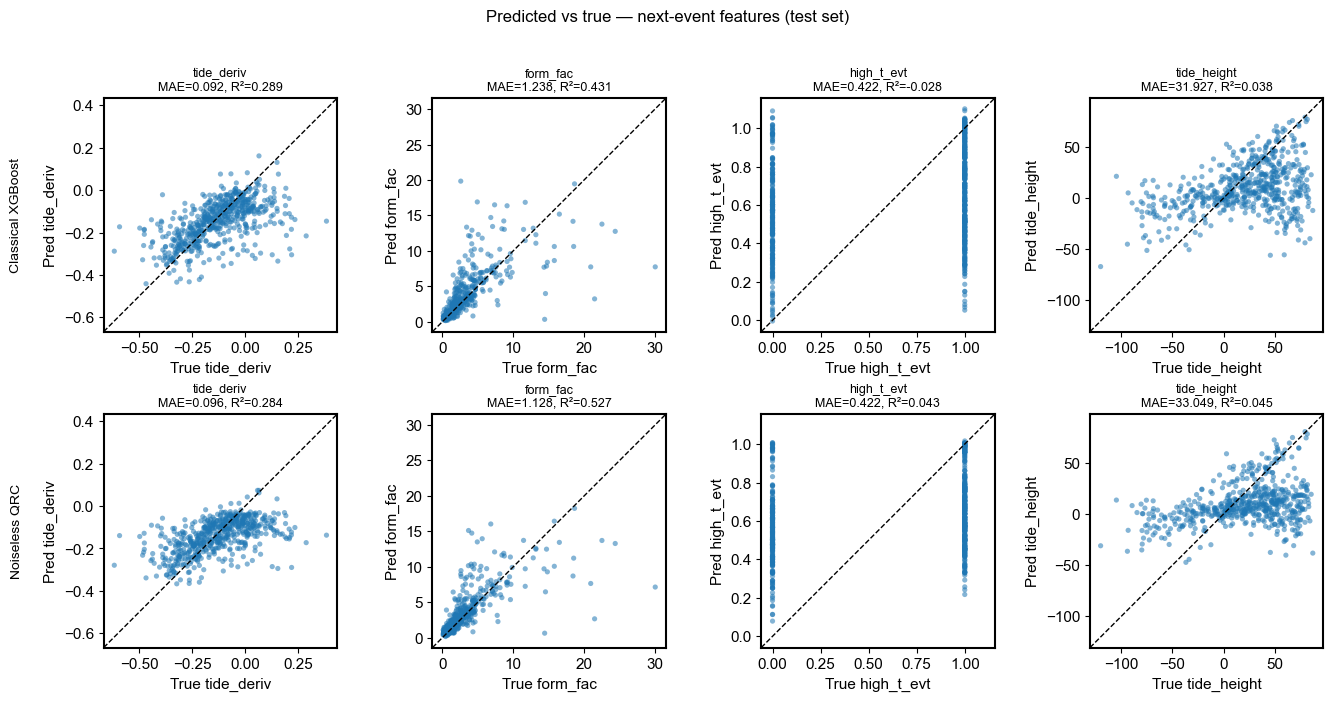


External noisy NN-TFI aggregate (scalar TTNS run — not 4-feature parity):
  topology:          nn
  ensemble_test_mae: 9243.06659084624
  ensemble_test_r2:  0.26694042508855065


In [15]:
# ── Cell 15: Publication figure — per-feature parity by model ───────────────
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from pathlib import Path

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.linewidth": 1.5,
    "axes.edgecolor": "black",
})

model_rows = [("Classical XGBoost", classical_pred)]
try:
    model_rows.append(("Noiseless QRC", as_target_matrix(ensemble_pred)))
except NameError:
    pass

n_rows = len(model_rows)
n_cols = len(TARGET_NAMES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 3.4 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]

feat_limits = []
for j in range(len(TARGET_NAMES)):
    vals = [y_test_true[:, j]]
    for _, preds in model_rows:
        vals.append(preds[:, j])
    all_v = np.concatenate(vals)
    lo, hi = float(all_v.min()), float(all_v.max())
    pad = (hi - lo) * 0.05 if hi > lo else 1.0
    feat_limits.append((lo - pad, hi + pad))

for i, (label, preds) in enumerate(model_rows):
    for j in range(len(TARGET_NAMES)):
        plot_feature_parity(
            axes[i, j], y_test_true, preds, j,
            title=TARGET_NAMES[j],
            limits=feat_limits[j],
        )
    axes[i, 0].annotate(
        label, xy=(-0.35, 0.5), xycoords="axes fraction",
        ha="right", va="center", fontsize=10, rotation=90,
    )

fig.suptitle("Predicted vs true — next-event features (test set)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

def _repo_root():
    cwd = Path.cwd().resolve()
    for c in (cwd, cwd.parent):
        if (c / "Classical" / "results").exists():
            return c
    return cwd

_noisy_summary_path = _repo_root() / "Classical" / "results" / "exp_nn_noisy" / "aggregate_summary_t0.05.json"
if _noisy_summary_path.exists():
    with _noisy_summary_path.open() as f:
        _noisy_agg = json.load(f)
    print("\nExternal noisy NN-TFI aggregate (scalar TTNS run — not 4-feature parity):")
    print(f"  topology:          {_noisy_agg.get('topology')}")
    print(f"  ensemble_test_mae: {_noisy_agg.get('ensemble_test_mae')}")
    print(f"  ensemble_test_r2:  {_noisy_agg.get('ensemble_test_r2')}")
else:
    print("\nNo external noisy aggregate summary found.")


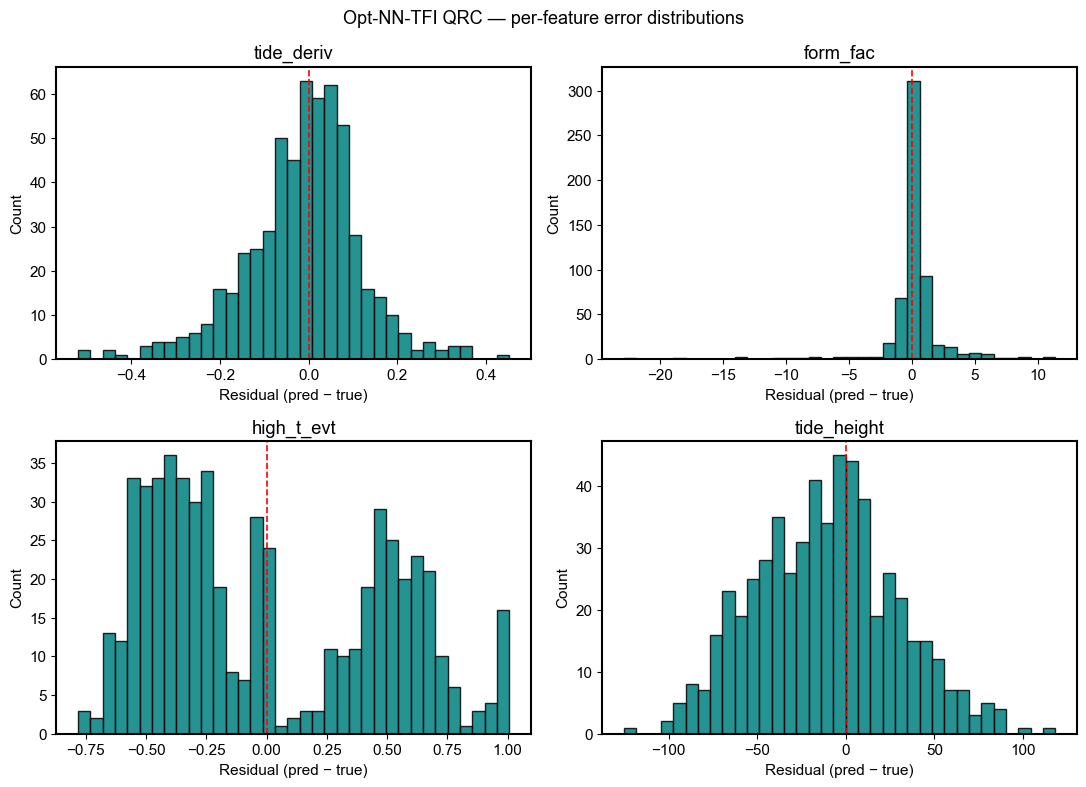

Overall MAE:  8.6737
Overall R²:   0.0481
Mean |error| per feature: [ 0.09576736  1.12808377  0.42214618 33.04894032]


In [16]:
# ── Cell 16: QRC residual distributions (per feature) ───────────────────────
import matplotlib.pyplot as plt
import numpy as np

if not _qrc_available:
    print("Run QRC pipeline first (ensemble_pred not found).")
else:
    residuals = qrc_pred - y_test_true
    abs_err = np.abs(residuals)

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    fig.suptitle("Opt-NN-TFI QRC — per-feature error distributions", fontsize=13)
    axes = axes.ravel()

    for j, ax in enumerate(axes):
        ax.hist(residuals[:, j], bins=35, color="teal", edgecolor="black", alpha=0.85)
        ax.axvline(0, color="red", linestyle="--", lw=1.2)
        ax.set_title(TARGET_NAMES[j])
        ax.set_xlabel("Residual (pred − true)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    print(f"Overall MAE:  {mean_absolute_error(y_test_true, qrc_pred):.4f}")
    print(f"Overall R²:   {multioutput_r2(y_test_true, qrc_pred):.4f}")
    print(f"Mean |error| per feature: {abs_err.mean(axis=0)}")


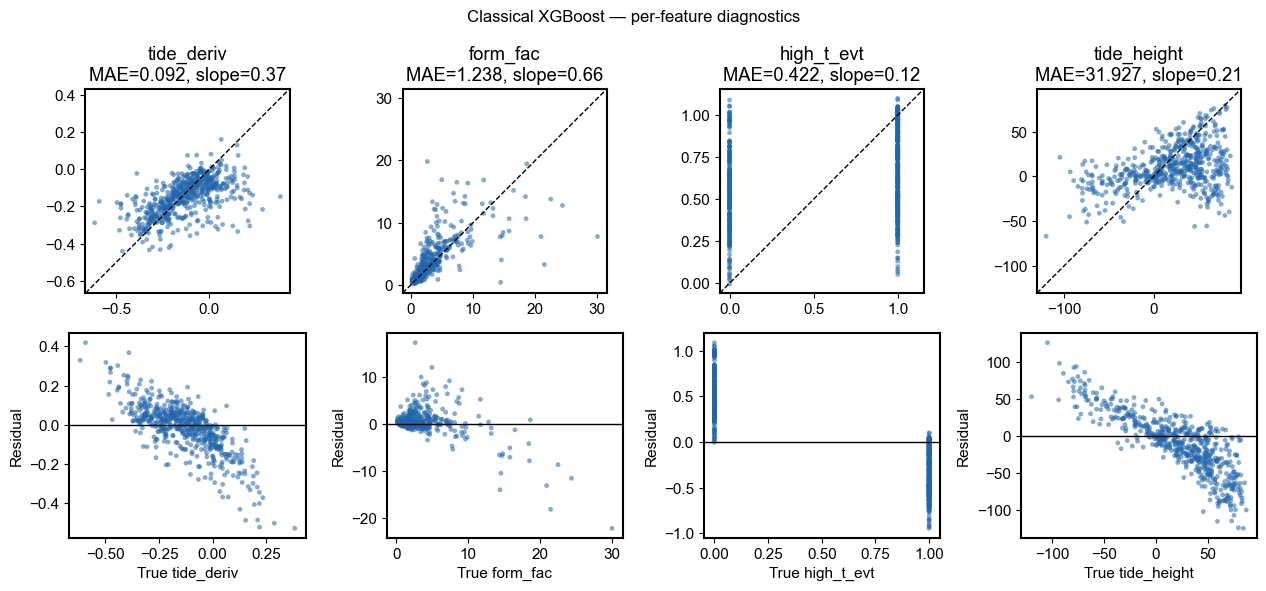

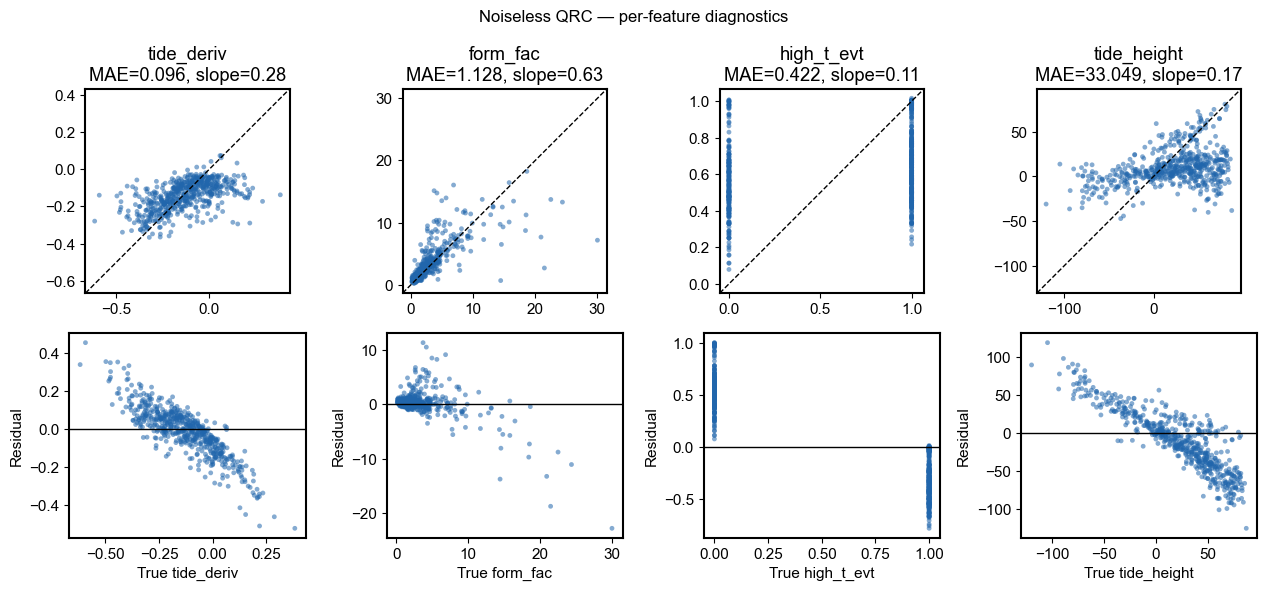

In [17]:
# ── Cell 17: Prediction diagnostics — parity + residual bias per feature ────
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

SCATTER_COL = "#2166ac"

def _draw_model_diagnostics(y_true, preds, label):
    fig, axes = plt.subplots(2, len(TARGET_NAMES), figsize=(3.2 * len(TARGET_NAMES), 6))
    fig.suptitle(f"{label} — per-feature diagnostics", fontsize=12)

    for j in range(len(TARGET_NAMES)):
        yt, yp = y_true[:, j], preds[:, j]
        signed = yp - yt
        lo, hi = feature_limits(yt, yp)

        ax_sc = axes[0, j]
        ax_sc.scatter(yt, yp, color=SCATTER_COL, s=12, alpha=0.55, edgecolors="none")
        ax_sc.plot([lo, hi], [lo, hi], "k--", lw=1.0)
        ax_sc.set_xlim(lo, hi)
        ax_sc.set_ylim(lo, hi)
        ax_sc.set_aspect("equal", adjustable="box")
        slope, intercept, *_ = linregress(yt, yp)
        ax_sc.set_title(f"{TARGET_NAMES[j]}\nMAE={np.mean(np.abs(signed)):.3f}, slope={slope:.2f}")

        ax_res = axes[1, j]
        ax_res.scatter(yt, signed, color=SCATTER_COL, s=12, alpha=0.55, edgecolors="none")
        ax_res.axhline(0, color="black", lw=1.0)
        ax_res.set_xlabel(f"True {TARGET_NAMES[j]}")
        ax_res.set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

_draw_model_diagnostics(y_test_true, classical_pred, "Classical XGBoost")
if _qrc_available:
    _draw_model_diagnostics(y_test_true, qrc_pred, "Noiseless QRC")


In [18]:
# ── Cell 18: Headline metrics summary ───────────────────────────────────────
print("=" * 70)
print("Multi-output test metrics (4 next-event features)")
print("=" * 70)
for label, preds in [("Classical XGBoost", classical_pred)] + (
    [("Noiseless QRC", qrc_pred)] if _qrc_available else []
):
    ps_mae = per_sample_mae(y_test_true, preds)
    print(f"\n{label}")
    print(f"  MAE (mean over features): {mean_absolute_error(y_test_true, preds):.4f}")
    print(f"  RMSE:                     {root_mean_squared_error(y_test_true, preds):.4f}")
    print(f"  R² (variance-weighted):   {multioutput_r2(y_test_true, preds):.4f}")
    print(f"  Per-sample MAE — median:  {np.median(ps_mae):.4f}, 90th pct: {np.percentile(ps_mae, 90):.4f}")
    for name, m in zip(TARGET_NAMES, per_feature_mae(y_test_true, preds)):
        print(f"    {name}: MAE={m:.4f}")
print("=" * 70)


Multi-output test metrics (4 next-event features)

Classical XGBoost
  MAE (mean over features): 8.4199
  RMSE:                     11.1739
  R² (variance-weighted):   0.0408
  Per-sample MAE — median:  6.7301, 90th pct: 18.5371
    tide_deriv: MAE=0.0921
    form_fac: MAE=1.2384
    high_t_evt: MAE=0.4217
    tide_height: MAE=31.9274

Noiseless QRC
  MAE (mean over features): 8.6737
  RMSE:                     11.0746
  R² (variance-weighted):   0.0481
  Per-sample MAE — median:  7.4106, 90th pct: 17.7811
    tide_deriv: MAE=0.0958
    form_fac: MAE=1.1281
    high_t_evt: MAE=0.4221
    tide_height: MAE=33.0489


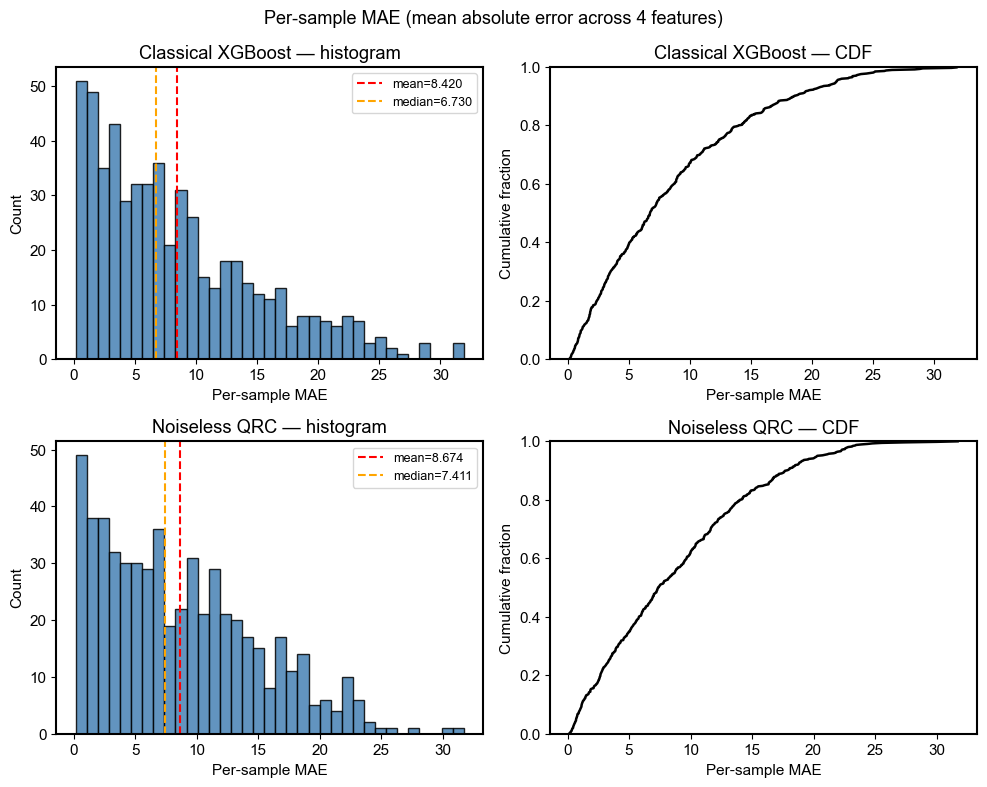

In [19]:
# ── Cell 19: Per-sample MAE distributions (Classical & QRC) ─────────────────
import matplotlib.pyplot as plt
import numpy as np

panels = [("Classical XGBoost", classical_pred)]
if _qrc_available:
    panels.append(("Noiseless QRC", qrc_pred))

n_rows = len(panels)
fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]
fig.suptitle("Per-sample MAE (mean absolute error across 4 features)", fontsize=13)

for i, (label, preds) in enumerate(panels):
    ps_mae = per_sample_mae(y_test_true, preds)

    ax = axes[i, 0]
    ax.hist(ps_mae, bins=35, color="steelblue", edgecolor="black", alpha=0.85)
    ax.axvline(ps_mae.mean(), color="red", linestyle="--", label=f"mean={ps_mae.mean():.3f}")
    ax.axvline(np.median(ps_mae), color="orange", linestyle="--", label=f"median={np.median(ps_mae):.3f}")
    ax.set_xlabel("Per-sample MAE")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} — histogram")
    ax.legend(fontsize=9)

    ax = axes[i, 1]
    xs = np.sort(ps_mae)
    cdf = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, cdf, color="black", lw=1.8)
    ax.set_xlabel("Per-sample MAE")
    ax.set_ylabel("Cumulative fraction")
    ax.set_title(f"{label} — CDF")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [20]:
# ── Cell 20: Per-sample results table ───────────────────────────────────────
import pandas as pd
import numpy as np

rows = {"sample_idx": np.arange(len(y_test_true))}
for j, name in enumerate(TARGET_NAMES):
    rows[f"true_{name}"] = y_test_true[:, j]
    rows[f"classical_{name}"] = classical_pred[:, j]
    rows[f"classical_abserr_{name}"] = np.abs(classical_pred[:, j] - y_test_true[:, j])
    if _qrc_available:
        rows[f"qrc_{name}"] = qrc_pred[:, j]
        rows[f"qrc_abserr_{name}"] = np.abs(qrc_pred[:, j] - y_test_true[:, j])

results_df = pd.DataFrame(rows)
results_df["classical_sample_mae"] = per_sample_mae(y_test_true, classical_pred)
if _qrc_available:
    results_df["qrc_sample_mae"] = per_sample_mae(y_test_true, qrc_pred)

results_df = results_df.sort_values("classical_sample_mae").reset_index(drop=True)

print("Per-sample results (sorted by classical per-sample MAE)")
print("=" * 100)
display(results_df.head(20).round(4))

print("\nSummary of per-sample MAE:")
summary_cols = ["classical_sample_mae"] + (["qrc_sample_mae"] if _qrc_available else [])
print(results_df[summary_cols].describe().round(4))


Per-sample results (sorted by classical per-sample MAE)


,sample_idx,true_tide_deriv,classical_tide_deriv,classical_abserr_tide_deriv,qrc_tide_deriv,qrc_abserr_tide_deriv,true_form_fac,classical_form_fac,classical_abserr_form_fac,qrc_form_fac,...,classical_abserr_high_t_evt,qrc_high_t_evt,qrc_abserr_high_t_evt,true_tide_height,classical_tide_height,classical_abserr_tide_height,qrc_tide_height,qrc_abserr_tide_height,classical_sample_mae,qrc_sample_mae
0,175,-0.1864,-0.0707,0.1158,-0.0174,0.1690,3.2313,3.4204,0.1892,2.2224,...,0.0130,0.9880,0.0120,47.5832,47.8094,0.2262,40.3300,7.2533,0.1360,2.1108
1,132,-0.2209,-0.1667,0.0542,-0.1861,0.0349,0.3962,0.5769,0.1807,0.6955,...,0.2477,0.6394,0.3606,11.8472,11.6752,0.1720,7.7898,4.0574,0.1636,1.1880
2,332,-0.1840,-0.2389,0.0549,-0.2129,0.0289,0.6096,0.7757,0.1661,0.6420,...,0.5296,0.6644,0.3356,1.6043,1.6352,0.0309,5.0520,3.4477,0.1954,0.9611
3,486,-0.1733,-0.1761,0.0028,-0.1974,0.0241,0.7833,0.7753,0.0080,0.7835,...,0.7349,0.7881,0.7881,-1.3564,-1.1763,0.1801,4.1335,5.4899,0.2314,1.5755
4,419,-0.4037,-0.3188,0.0849,-0.2879,0.1158,0.7548,0.4032,0.3516,0.8078,...,0.2105,0.6656,0.3344,19.8324,19.4874,0.3450,10.2411,9.5913,0.2480,2.5236
5,224,-0.2180,-0.2403,0.0223,-0.2344,0.0164,0.5053,0.3803,0.1249,0.4678,...,0.4670,0.4553,0.4553,-0.6988,-1.1476,0.4488,-3.3679,2.6691,0.2658,0.7946
6,169,-0.3890,-0.2207,0.1683,-0.2266,0.1623,0.4681,0.1590,0.3091,0.1724,...,0.3783,0.7994,0.2006,6.7977,6.5860,0.2118,9.1408,2.3431,0.2669,0.7504
7,500,-0.3129,-0.2119,0.1009,-0.1752,0.1377,0.9563,0.9558,0.0005,1.0930,...,0.2887,0.2699,0.2699,-2.8813,-2.1311,0.7502,-2.4285,0.4528,0.2851,0.2493
8,308,-0.1588,-0.1685,0.0097,-0.1702,0.0115,0.9637,0.9892,0.0255,1.6835,...,0.3360,0.7775,0.2225,3.6349,4.4913,0.8564,15.5115,11.8765,0.3069,3.2076
9,378,-0.3096,-0.2647,0.0449,-0.2393,0.0702,0.9868,1.2799,0.2930,1.5433,...,0.0132,1.0015,0.0015,40.7119,41.6235,0.9116,39.3997,1.3122,0.3157,0.4851



Summary of per-sample MAE:
       classical_sample_mae  qrc_sample_mae
count              565.0000        565.0000
mean                 8.4199          8.6737
std                  6.7451          6.2906
min                  0.1360          0.1629
25%                  2.9710          3.3615
50%                  6.7301          7.4106
75%                 12.4021         12.7359
max                 31.9109         31.7149
